# CodeAlpha 
## Task 02: Exploratory Data Analysis (EDA) on Covid-19 Data Set


### 1: Import Libraries 

In [6]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2: Load Data set

In [7]:
df = pd.read_csv('country_wise_latest.csv')

### 3: Basic Information

In [8]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [9]:
df.shape

(187, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [11]:
cols = ['Deaths / 100 Cases', 
        'Recovered / 100 Cases', 
        '1 week % increase']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

### 4: Check Missing Values

In [13]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

### 5: Check the Duplicates Values 

In [14]:
df.duplicated().sum()

np.int64(0)

### 6: Univariate Analysis

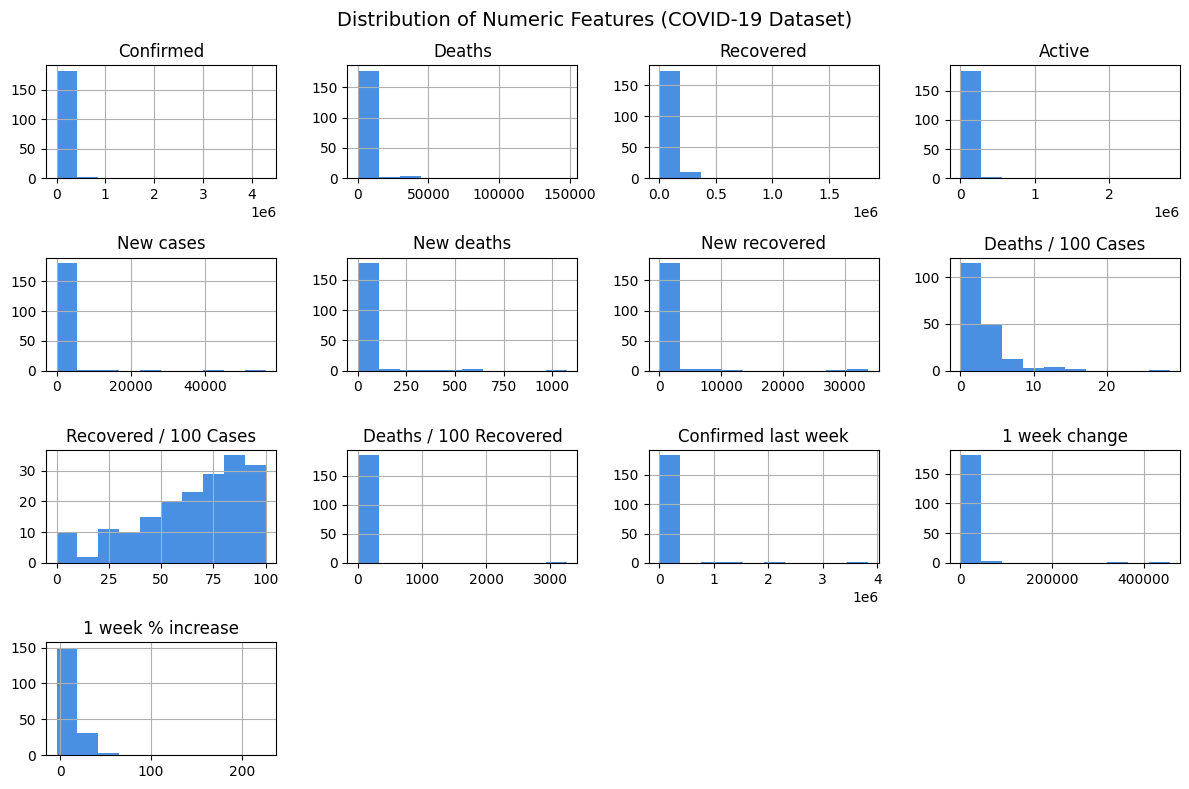

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Clean data
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

numeric_df = df.select_dtypes(include=['number'])

# Professional colors
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B', '#9013FE']

numeric_df.hist(figsize=(12, 8), bins=10, color=colors[0])

plt.suptitle("Distribution of Numeric Features (COVID-19 Dataset)", fontsize=14)
plt.tight_layout()
plt.show()

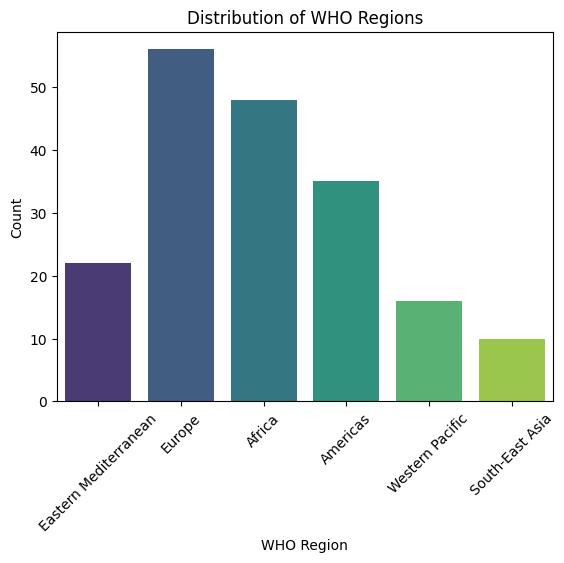

In [16]:
import seaborn as sns

sns.countplot(
    x='WHO Region',
    data=df,
    hue='WHO Region',      # 👈 adds separate color per category
    palette='viridis',
    legend=False           # remove duplicate legend
)

plt.xticks(rotation=45)
plt.title('Distribution of WHO Regions')
plt.xlabel('WHO Region')
plt.ylabel('Count')
plt.show()

### 7: BIVARIATE ANALYSIS 

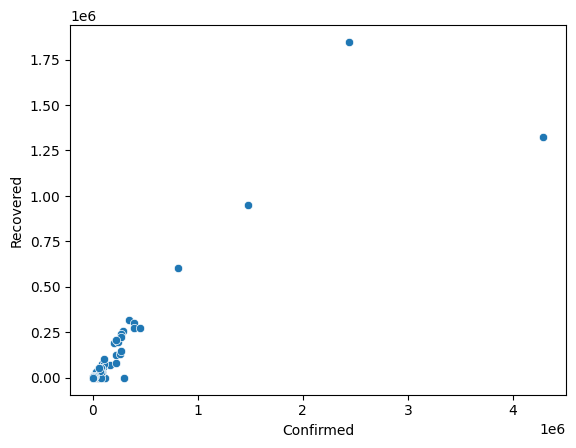

In [17]:
# Scatter plot
sns.scatterplot(x='Confirmed', y='Recovered', data=df)
plt.show()

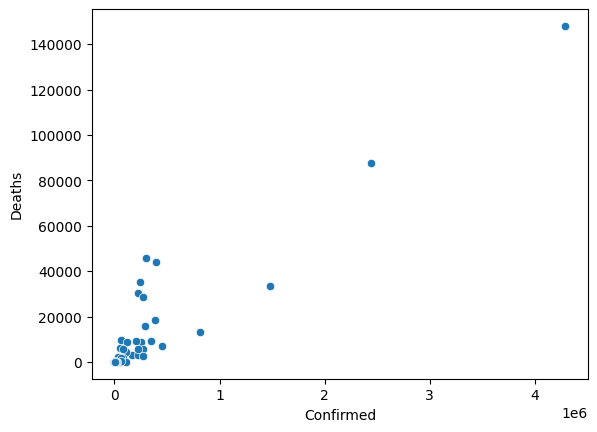

In [18]:
sns.scatterplot(x='Confirmed', y='Deaths', data=df)
plt.show()

In [19]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

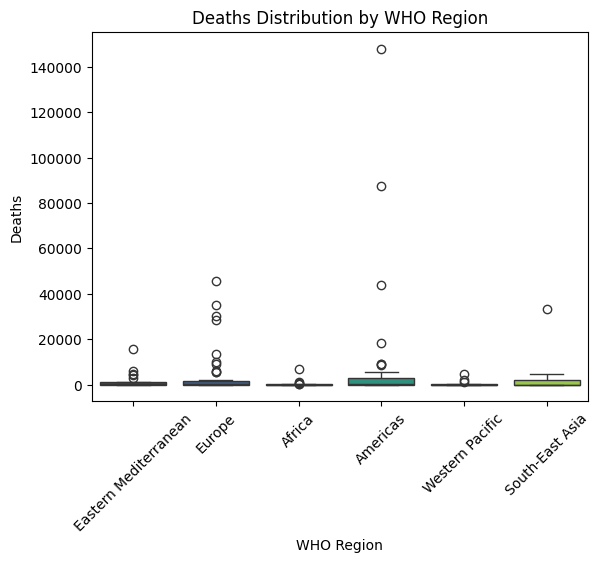

In [20]:
# Box plot
sns.boxplot(
    x='WHO Region',
    y='Deaths',
    data=df,
    hue='WHO Region',   # adds separate color per region
    palette='viridis',
    dodge=False
)

plt.xticks(rotation=45)
plt.xlabel('WHO Region')
plt.ylabel('Deaths')
plt.title('Deaths Distribution by WHO Region')
plt.legend([],[], frameon=False)  # removes extra legend
plt.show()

### 8: CORRELATION ANALYSIS

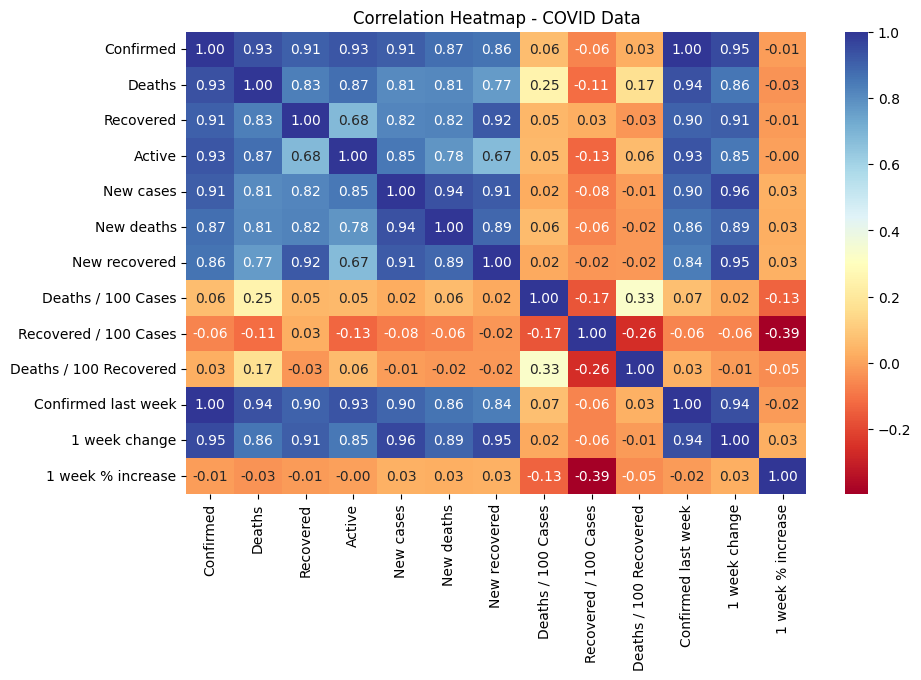

In [21]:
plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu',   # red → yellow → blue (very clear differences)
    fmt='.2f'
)

plt.title("Correlation Heatmap - COVID Data")
plt.show()

=========================
### 8: OUTLIERS DETECTION
=========================

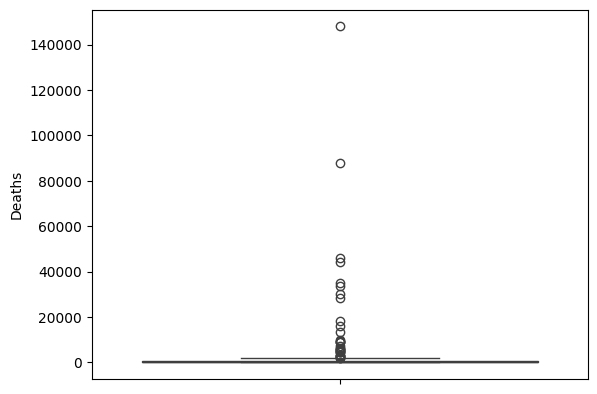

     Country/Region  Confirmed  Deaths  Recovered   Active  New cases  \
6         Argentina     167416    3059      72575    91782       4890   
13       Bangladesh     226225    2965     125683    97577       2772   
16          Belgium      66428    9822      17452    39154        402   
20          Bolivia      71181    2647      21478    47056       1752   
23           Brazil    2442375   87618    1846641   508116      23284   
32           Canada     116458    8944          0   107514        682   
35            Chile     347923    9187     319954    18782       2133   
36            China      86783    4656      78869     3258        213   
37         Colombia     257101    8777     131161   117163      16306   
51          Ecuador      81161    5532      34896    40733        467   
52            Egypt      92482    4652      34838    52992        420   
61           France     220352   30212      81212   108928       2551   
65          Germany     207112    9125     190314  

In [22]:
sns.boxplot(df['Deaths'])
plt.show()

# IQR method (correct)
Q1 = df['Deaths'].quantile(0.25)
Q3 = df['Deaths'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Deaths'] < Q1 - 1.5*IQR) |
              (df['Deaths'] > Q3 + 1.5*IQR)]

print(outliers)


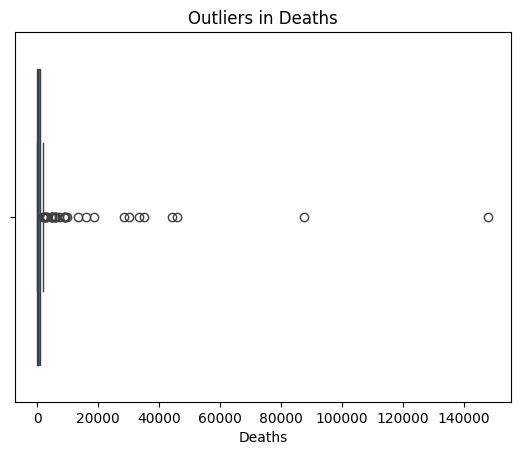

In [23]:
sns.boxplot(x=df['Deaths'])
plt.title("Outliers in Deaths")
plt.show()

=======================
### 10: GROUP ANALYSIS
=======================

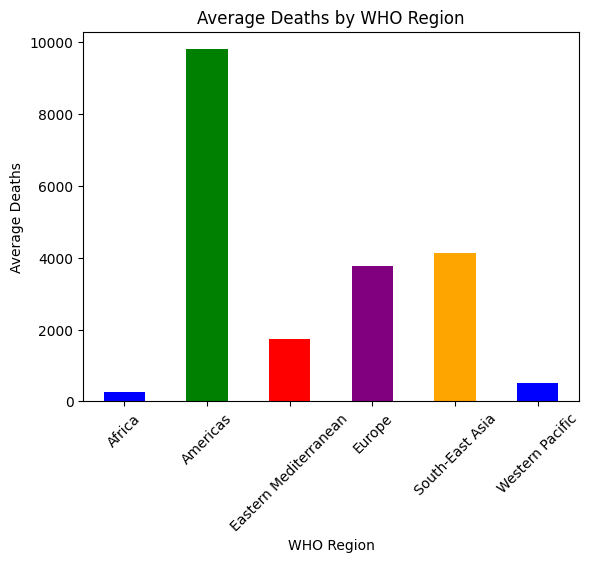

In [24]:
df.groupby('WHO Region')['Deaths'].mean().plot(
    kind='bar',
    color=['blue', 'green', 'red', 'purple', 'orange']
)

plt.title('Average Deaths by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Average Deaths')
plt.xticks(rotation=45)
plt.show()

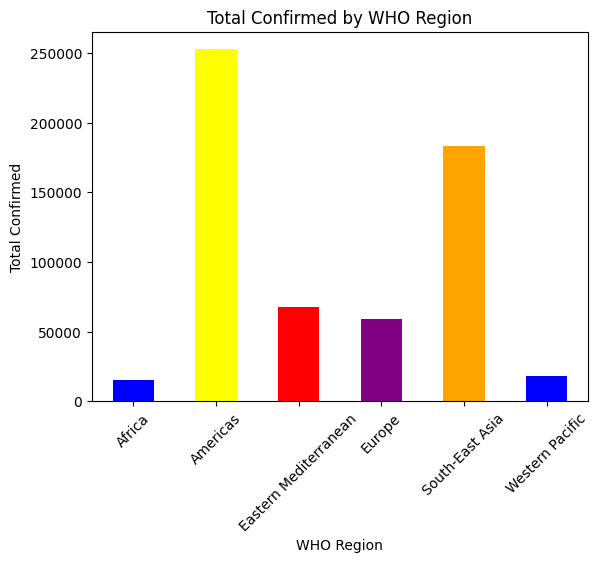

In [25]:
df.groupby('WHO Region')['Confirmed'].mean().plot(
    kind='bar',
    color=['blue', 'yellow', 'red', 'purple', 'orange']
)

plt.title('Total Confirmed by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Total Confirmed')
plt.xticks(rotation=45)
plt.show()

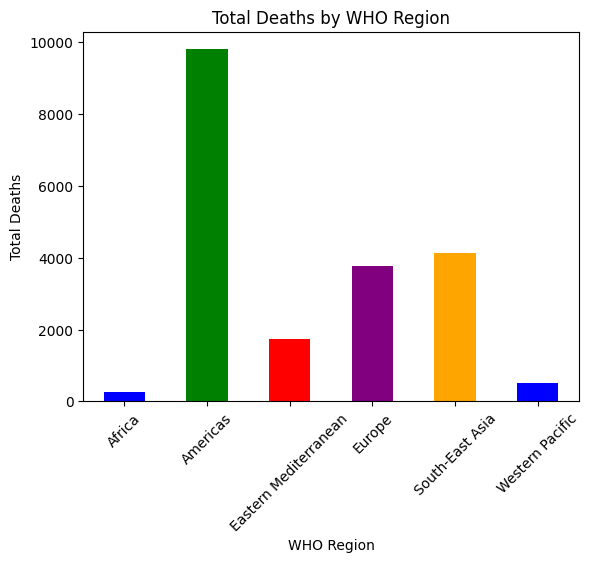

In [26]:
df.groupby('WHO Region')['Deaths'].mean().plot(
    kind='bar',
    color=['blue', 'green', 'red', 'purple', 'orange']
)

plt.title('Total Deaths by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.show()

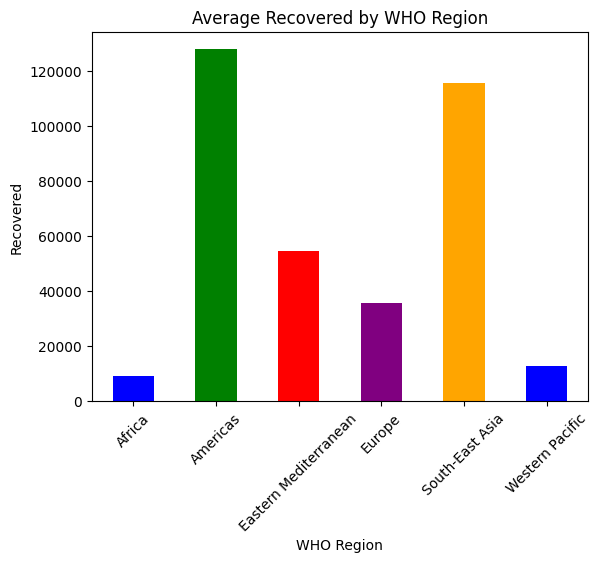

In [27]:
df.groupby('WHO Region')['Recovered'].mean().plot(
    kind='bar',
    color=['blue', 'green', 'red', 'purple', 'orange']
)

plt.title('Average Recovered by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Recovered')
plt.xticks(rotation=45)
plt.show()

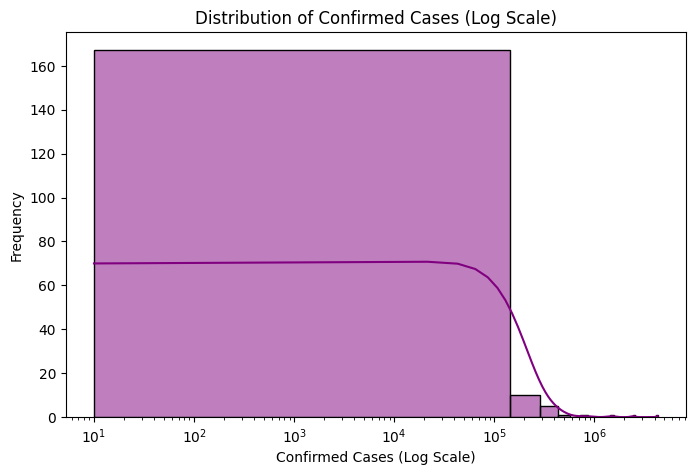

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Confirmed'], bins=30, kde=True, color='purple')

plt.xscale('log')   # 👈 important for skewed data

plt.title('Distribution of Confirmed Cases (Log Scale)')
plt.xlabel('Confirmed Cases (Log Scale)')
plt.ylabel('Frequency')

plt.show()